In [93]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df = pd.read_excel("izmir_houses.xlsx")

### A.1 EDA

In [95]:
print(df.head())

                           District     Price  \
0   İzmir / Güzelbahçe / Çamlı Mah.   7000000   
1  İzmir / Güzelbahçe / Çelebi Mah.  35000000   
2    İzmir / Torbalı / Torbalı Mah.   6500000   
3    İzmir / Selçuk / 14 Mayıs Mah.   3750000   
4       İzmir / Buca / Adatepe Mah.   1410000   

                              Rooms  Size_m2  \
0  5 +\n                          2    260.0   
1  4 +\n                          1    270.0   
2  3 +\n                          1    195.0   
3  2 +\n                          1     75.0   
4  2 +\n                          1    110.0   

                                   Age  
0   1\n                        Yaşında  
1  25\n                        Yaşında  
2   8\n                        Yaşında  
3  10\n                        Yaşında  
4                           Sıfır Bina  


In [96]:
print(df.columns)

Index(['District', 'Price', 'Rooms', 'Size_m2', 'Age'], dtype='object')


In [97]:
print(df.shape)

(979, 5)


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 979 entries, 0 to 978
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   District  979 non-null    object 
 1   Price     979 non-null    int64  
 2   Rooms     979 non-null    object 
 3   Size_m2   979 non-null    float64
 4   Age       979 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 38.4+ KB


## A.2 Data Cleaning

In [99]:
#Functions to clean

def clean_room_count(text):
    if pd.isna(text): return None
    text = str(text)
    if "Stüdyo" in text: return 1
    if "+" in text:
        try:
            parts = text.split("+")
            return int(parts[0]) + int(parts[1])
        except: return None
    try: return int(text)
    except: return None

def clean_age(text):
    if pd.isna(text): return None
    text = str(text)
    if "Sıfır" in text: return 0 # "Sıfır" means zero
    try: return int(text.split(" ")[0]) #10 yaşında -> 10
    except: return None

def clean_district(text):
    # "İzmir / Bornova / Erzene Mah." -> "Bornova"
    try:
        return text.split("/")[1].strip()
    except:
        return text

# Applying the functions
df['Rooms'] = df['Rooms'].apply(clean_room_count)
df['Age'] = df['Age'].apply(clean_age)
df['District'] = df['District'].apply(clean_district)

# Converting to numbers
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Size_m2'] = pd.to_numeric(df['Size_m2'], errors='coerce')
# Dropped null rows
df_clean = df.dropna()
print(f"Cleaned Data: {len(df_clean)} rows.")
df_clean.head()

Cleaned Data: 979 rows.


,District,Price,Rooms,Size_m2,Age
0,Güzelbahçe,7000000,7,260.0,1
1,Güzelbahçe,35000000,5,270.0,25
2,Torbalı,6500000,4,195.0,8
3,Selçuk,3750000,3,75.0,10
4,Buca,1410000,3,110.0,0


## Visual Analysis

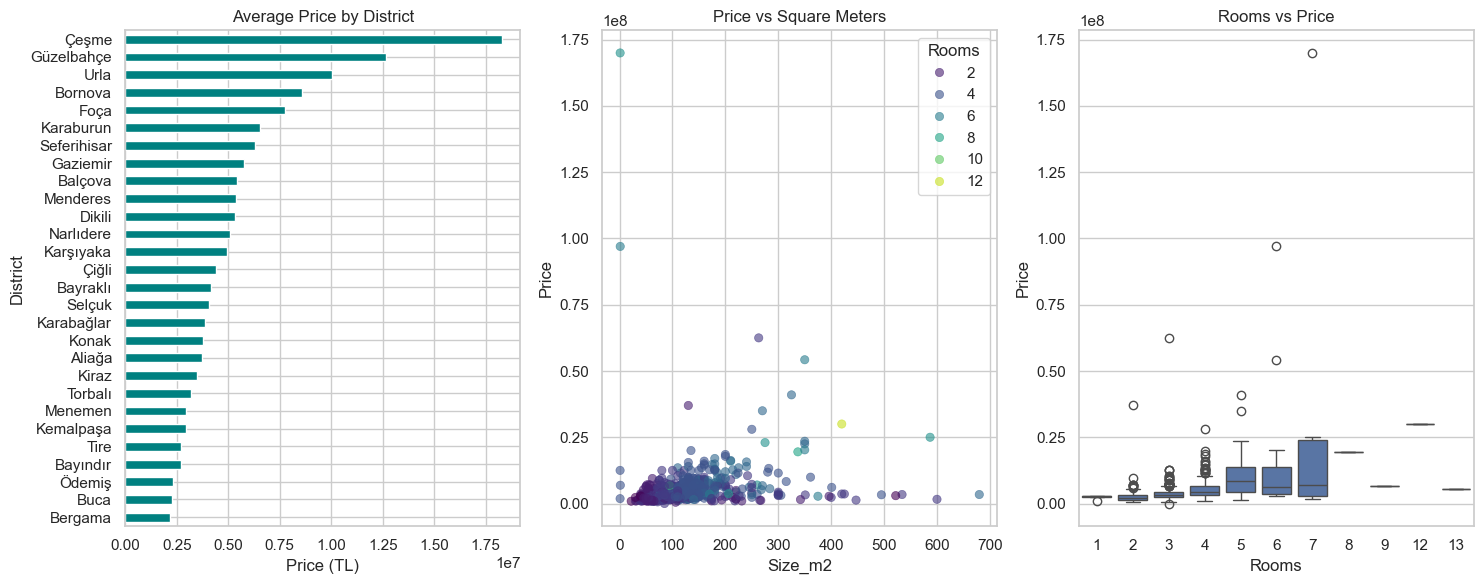

In [100]:
sns.set(style="whitegrid")
plt.figure(figsize=(15,6))

# Price Distribution by District
plt.subplot(1, 3, 1)
# Group by district, calculate average price, sort it
district_price = df_clean.groupby('District')['Price'].mean().sort_values()
district_price.plot(kind='barh', color='teal')
plt.title('Average Price by District')
plt.xlabel('Price (TL)')

# CHART 2: Price vs Size (m2)
plt.subplot(1, 3, 2)
sns.scatterplot(data=df_clean, x='Size_m2', y='Price', hue='Rooms', palette='viridis', alpha=0.6, edgecolor=None)
plt.title('Price vs Square Meters')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# Rooms vs Price
plt.subplot(1, 3, 3)
sns.boxplot(x='Rooms', y='Price', data=df_clean)
plt.title("Rooms vs Price")
plt.tight_layout()
plt.show()

-Especially seaside districts have higher average prices.

-We can see that there are some extreme values in the dataset that may affect the model's performance.

-After 5th room price reduces unexpectedly.



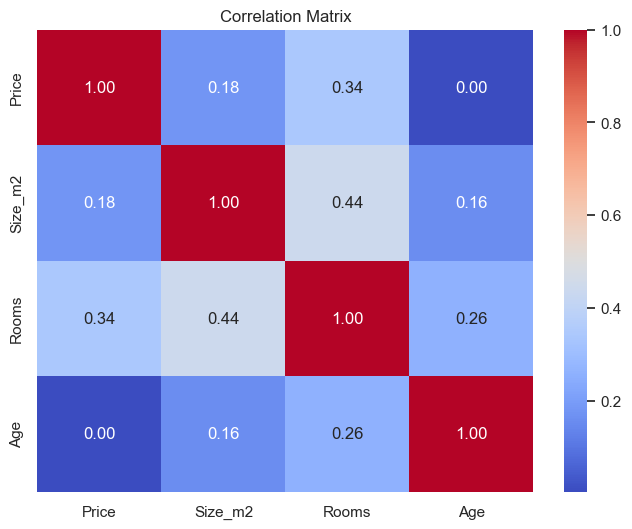

In [101]:
# Correlation Matrix
plt.figure(figsize=(8,6))
corr = df_clean[['Price', 'Size_m2', 'Rooms', 'Age']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

I realize that these correlations aren't what is expected especially size_m2 It should've been higher correlation with price. I will recheck the cleaning functions and data types.

In [102]:
# 1. Checking for non realistic sizes
print("Unrealistic small houses (< 30m2)\n")
print(df_clean[df_clean['Size_m2'] < 30][['District', 'Price', 'Size_m2', 'Rooms']])

print("\nUnrealistic big houses (> 400m2)")
print(df_clean[df_clean['Size_m2'] > 400][['District', 'Price', 'Size_m2', 'Rooms']])

# 2. Checking for non realistic Prices per 1 m2
df_clean['Price_per_m2'] = df_clean['Price'] / df_clean['Size_m2']

print("\nCheapest Prices per m2 (Likely Errors or Land)")#cheapest
print(df_clean.sort_values('Price_per_m2').head(5)[['District', 'Price', 'Size_m2', 'Price_per_m2']])

print("\nMost Expensive Prices per m2")#expensive ones
print(df_clean.sort_values('Price_per_m2', ascending=False).head(10)[['District', 'Price', 'Size_m2', 'Price_per_m2']])

print("\n Oldest Houses")
print(df_clean.sort_values('Age', ascending=False).head(10)[['District', 'Price', 'Size_m2', 'Age']])

Unrealistic small houses (< 30m2)

     District      Price  Size_m2  Rooms
9    Menderes    6900000     1.50      4
60   Menderes   12500000     1.00      4
104     Çeşme   97000000     1.25      6
182    Aliağa    1850000     1.00      4
278     Konak     880000    22.00      1
684   Bornova  170000000     1.10      7

Unrealistic big houses (> 400m2)
     District     Price  Size_m2  Rooms
161   Bergama   1599000    600.0      3
441  Menderes   3400000    680.0      5
461    Ödemiş   3600000    420.0      3
463   Bergama   3400000    534.0      3
612     Konak  25000000    587.0      7
618   Torbalı   3300000    495.0      4
716   Balçova  30000000    420.0     12
737   Bergama   1300000    447.0      3
951  Menderes   6099000    401.0      4
953  Menderes   3600000    425.0      3
975      Buca   2975000    522.0      1

Cheapest Prices per m2 (Likely Errors or Land)
     District    Price  Size_m2  Price_per_m2
592  Menderes     5500     85.0     64.705882
161   Bergama  1599000  

In [103]:
print(f"*Before removal row count: {len(df_clean)}")
print()
df_clean = df_clean[df_clean['Price'] > 500000] # removing low prices <500k
df_clean = df_clean[df_clean['Price'] < 100000000] # removing high prices >100m

df_clean = df_clean[df_clean['Size_m2'] < 400]
df_clean = df_clean[df_clean['Size_m2'] > 30]

df_clean = df_clean[df_clean['Age'] < 90] # removing very old houses
print(f"*After removal row count: {len(df_clean)}")


*Before removal row count: 979

*After removal row count: 955


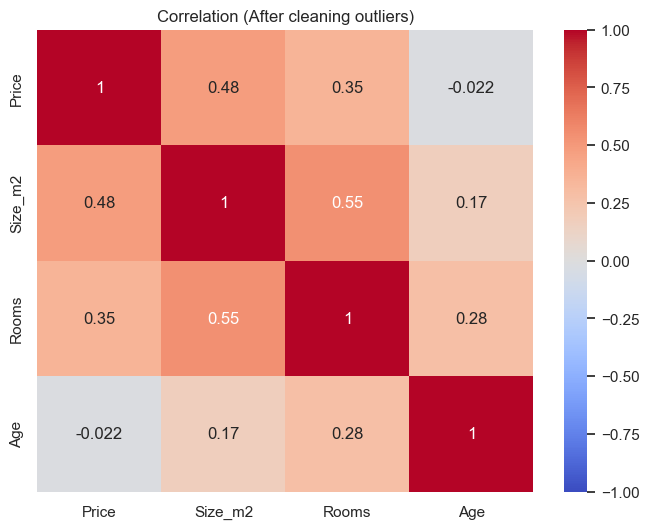

In [104]:
plt.figure(figsize=(8, 6))
correlation = df_clean[['Price', 'Size_m2', 'Rooms', 'Age']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation (After cleaning outliers)')
plt.show()

We did manual outlier removal and now correlation looks better. (price vs size increased 0.18 -> 0.48)
we see that age has a negative correlation but really close to 0.

### Correlation per District Heatmap

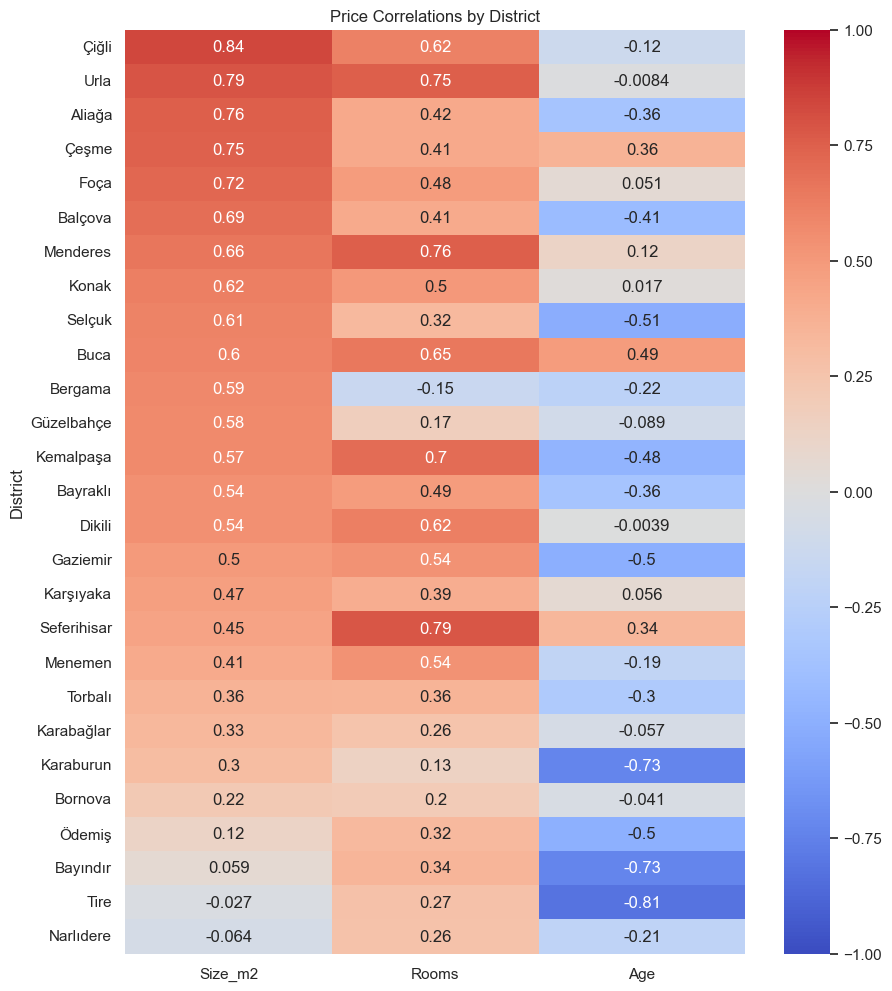

In [105]:

# We group by District, calculate correlations, and then grab just the 'Price' column
district_corrs = df_clean.groupby('District')[['Price', 'Size_m2', 'Rooms', 'Age']].corr().unstack()['Price']

# Drop the 'Price' column (because correlation of Price vs Price is always 1.0)
district_corrs = district_corrs.drop(columns=['Price'])

# Remove districts with NaN values
district_corrs = district_corrs.dropna()

# Sorting by 'Size_m2' 
district_corrs = district_corrs.sort_values(by='Size_m2', ascending=False)

# 3. PLOT THE MASTER HEATMAP
plt.figure(figsize=(10, 12)) # Tall chart to fit all districts
sns.heatmap(district_corrs, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Price Correlations by District')
plt.show()

Now we see that Size_m2 is the most important factor for price in almost all districts. Some districts probably have pools or gardens breaks the logic. So we are gonna add tier feature to the model as well.

## B. Using K-means method to cluster districts by avg prices because there is non linear relationship.

### 1. Deciding the most optimized k (Elbow Method)

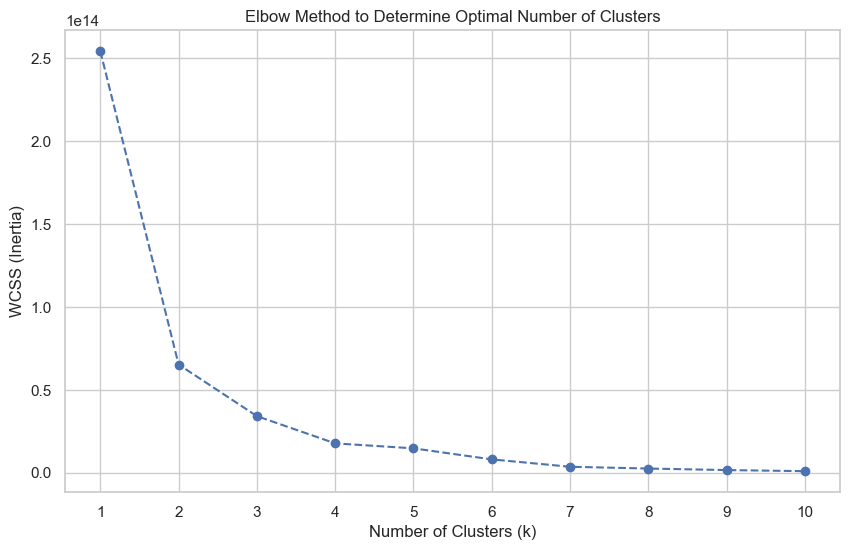

In [106]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Grouping by district to find avg. price
district_stats = df_clean.groupby('District')['Price'].mean().reset_index()

wcss = [] # Within cluster Sum of Squares
k_range = range(1, 11) # k from 1 to 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(district_stats[['Price']])
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### 2. Applying K-Means Algorithm


In [107]:
# After using elbow method we determined optimal k=4
optimal_k = 4 
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(district_stats[['Price']])

# sorting clusters (Tier 1 lowest, Tier 4 highest)
# Geting the cluster centers and sort indices
sorted_idx = kmeans.cluster_centers_.flatten().argsort()
# Creating a map: {original_label: sorted_rank} (0 to 3) -> (1 to 4)
rank_map = {original: rank + 1 for rank, original in enumerate(sorted_idx)}

# applying the mapping to get correct Tiers (1-4)
district_stats['Tier'] = kmeans.labels_
district_stats['Tier'] = district_stats['Tier'].map(rank_map)

print(f"District Tiers (k={optimal_k}):")
print(district_stats.sort_values('Price'))

# Creating a dictionary for mapping District -> Tier
district_tier_dict = dict(zip(district_stats['District'], district_stats['Tier']))

# applying to the main dataframe
df_clean['Tier'] = df_clean['District'].map(district_tier_dict)

District Tiers (k=4):
       District         Price  Tier
4       Bergama  2.181818e+06     1
6          Buca  2.250417e+06     1
27       Ödemiş  2.337500e+06     1
22         Tire  2.720909e+06     1
14    Kemalpaşa  2.950000e+06     1
3      Bayındır  2.968333e+06     1
18      Menemen  2.969340e+06     1
23      Torbalı  3.198677e+06     1
15        Kiraz  3.500000e+06     1
16        Konak  3.584794e+06     1
11   Karabağlar  3.865615e+06     1
0        Aliağa  3.967143e+06     1
21       Selçuk  4.083889e+06     1
2      Bayraklı  4.180270e+06     1
5       Bornova  4.225405e+06     1
26        Çiğli  4.409342e+06     2
1       Balçova  4.483846e+06     2
13    Karşıyaka  4.917198e+06     2
19    Narlıdere  5.070000e+06     2
7        Dikili  5.341644e+06     2
17     Menderes  5.410809e+06     2
9      Gaziemir  5.786765e+06     2
20  Seferihisar  6.277195e+06     2
12    Karaburun  7.121500e+06     3
8          Foça  7.757917e+06     3
24         Urla  1.005740e+07     3
10   G

## C. Training final model

### C.1 Finding best model

In [108]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# preparing data
X = df_clean[['Rooms', 'Size_m2', 'Tier', 'Age']]
y = df_clean['Price']

# splitting train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# models to test
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

print("Model Comparison:")
print("-" * 60)
print(f"{'Model':<20} | {'MAE':<15} | {'R2 Score':<10}")
print("-" * 60)

best_model_name = ""
lowest_mae = float('inf') # mean absolute error (lower better)
best_model = None

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results.append({"Model": name, "MAE": mae, "R2": r2})
    print(f"{name:<20} | {mae:,.0f} TL      | {r2:.4f}")
    
    if mae < lowest_mae:
        lowest_mae = mae
        best_model_name = name
        best_model = model

print("-" * 60)
print(f"\nBest Model according to MAE: {best_model_name}")

Model Comparison:
------------------------------------------------------------
Model                | MAE             | R2 Score  
------------------------------------------------------------
Linear Regression    | 1,725,883 TL      | 0.4389
Decision Tree        | 1,685,737 TL      | 0.3478
Random Forest        | 1,272,481 TL      | 0.7346
Gradient Boosting    | 1,320,526 TL      | 0.6955
------------------------------------------------------------

Best Model according to MAE: Random Forest
Gradient Boosting    | 1,320,526 TL      | 0.6955
------------------------------------------------------------

Best Model according to MAE: Random Forest


### C.2 Training final model

In [109]:
import pickle #pickle module to freeze the model

print(f"*Training final model with: {best_model_name}...")

# using the best model 
final_model = best_model
final_model.fit(X, y)

# Saving those into pickle files
pickle.dump(final_model, open("model.pkl", "wb"))
# We save the dictionary so the app knows which district is in which tier directly
pickle.dump(district_tier_dict, open("district_tiers.pkl", "wb")) 

print("Training complete.")
print("Check your folder for 'model.pkl' and 'district_tiers.pkl'.")

*Training final model with: Random Forest...
Training complete.
Check your folder for 'model.pkl' and 'district_tiers.pkl'.
